In [1]:
import pandas as pd
import dask.dataframe as dd
import numpy as np
from src.model_pipeline import ModelPipeline

# Import Data

In [2]:
# df_final = pd.read_parquet("data/feature_engineering/credit/df_credit_final.parquet")
df_final = pd.read_parquet("data/feature_engineering/credit/v3/df_credit_final.parquet")

In [3]:
df_final = df_final.set_index("Transaction Serial No", drop=True)

# Train

In [4]:
# setup pipeline
pipeline = ModelPipeline(
    model_type="lightgbm_balanced",
    random_state=42
)

Initializing ModelPipeline with model type: lightgbm_balanced
Retrieving model instance for type: lightgbm_balanced


# Splitting Train and Out-of-Sample (OOS)

In [5]:
split_date = "2025-05-01"

In [6]:
df_splits = pipeline.split_data_by_date(
    df=df_final,
    date_column="Transaction Datetime",
    split_date=split_date
)

Splitting data by date (pre-preprocessing)...
Train samples: 1197282, Test samples: 201546
Data splitting complete.


# OverSampling Minority Class on Train Data

In [7]:
from src.imbalance_learn import ImbalancedSampler

In [8]:
# prepare data
target_col = "Confirmed"
X, y = pipeline.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_training=True
)

Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
  Float columns to downcast: ['time_diff', 'TxnCount_L15M', 'TxnCount_L1H', 'TxnCount_L1D', 'TxnCount_L7D', 'TxnCount_L14D', 'TxnCount_L30D', 'TxnCount_L90D', 'TxnCount_to_MCC_L15M', 'TxnCount_to_MCC_L1H', 'TxnCount_to_MCC_L1D', 'TxnCount_to_MCC_L7D', 'TxnCount_to_MCC_L14D', 'TxnCount_to_MCC_L30D', 'TxnCount_to_MCC_L90D', 'TxnCount_to_MCC_details_L15M', 'TxnCount_to_MCC_details_L1H', 'TxnCount_to_MCC_details_L1D', 'TxnCount_to_MCC_details_L7D', 'TxnCount_to_MCC_details_L14D', 'TxnCount_to_MCC_details_L30D', 'TxnCount_to_MCC_details_L90D', 'TxnCount_to_MCC_catcode_L15M', 'TxnCount_to_MCC_catcode_L1H', 'TxnCount_to_MCC_catcode_L1D', 'TxnCount_to_MCC_catcode_L7D', 'TxnCount_to_MCC_catcode_L14D', 'TxnCount_to_MCC_catcode_L30D', 'TxnCount_to_MCC_catcode_L90D', 'TxnCount_to_MCC_cat_L15M', 'TxnCount_to_MCC_cat_L1H', 'TxnCount_to_MCC_cat_L1D', 'TxnCount_to_MCC_cat_L7D', 'TxnCount_to_MCC_cat_L14D', 'TxnCount

In [9]:
# split data
X_train, X_test, y_train, y_test = pipeline.split_data(X, y, test_size=0.3)

Splitting data into train and test sets...
Data splitting complete.


In [22]:
# OverSampling
ros_sampler = ImbalancedSampler(
    algorithm='RandomOverSampler',
    sampler_type='upsample',
    target_ratio=0.2, # 20% -> number of Fraud/Non-Fraud
    random_state=1234
)

X_train_ros, y_train_ros = ros_sampler.fit_resample(X_train, y_train)

Original dataset shape: Counter({False: 831875, True: 6222})
Resampled dataset shape using RandomOverSampler: Counter({False: 831875, True: 166375})


In [23]:
# build and train
pipeline.build_pipeline()
pipeline.train(X_train_ros, y_train_ros, show_training_log=False)

Building pipeline...
Pipeline built.
Training model...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 166375, number of negative: 831875
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.432784 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 54445
[LightGBM] [Info] Number of data points in the train set: 998250, number of used features: 256
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Model training complete.


In [24]:
# Evaluate
test_results = pipeline.evaluate(X_test, y_test)

Evaluating model...
Accuracy: 0.9978
AUC: 0.9975
PR AUC: 0.9304
Precision: 0.8159
Recall: 0.9040

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00    356518
        True       0.82      0.90      0.86      2667

    accuracy                           1.00    359185
   macro avg       0.91      0.95      0.93    359185
weighted avg       1.00      1.00      1.00    359185



# Model Evaluation

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
def plot_confusion_matrix(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = 0.5
):
    y_pred = (y_prob >= threshold).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    
    # plot using seaborn heatmap
    tn, fp, fn, tp = cm.ravel()
    labels = ["Non-Fraud", "Fraud"]
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    print(f"Recall/True Positive Rate: The model got {np.round(tp/(tp+fn)*100, 2)}% of correctly predicted fraud from all of the actual fraud transactions")
    print(f"Precision: The model got {np.round(tp/(tp+fp)*100, 2)}% of correctly predicted fraud from all transactions that predicted as fraud")
    print(f"False Positive Rate: The model got {np.round(fp/(fp+tn)*100, 2)}% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud")

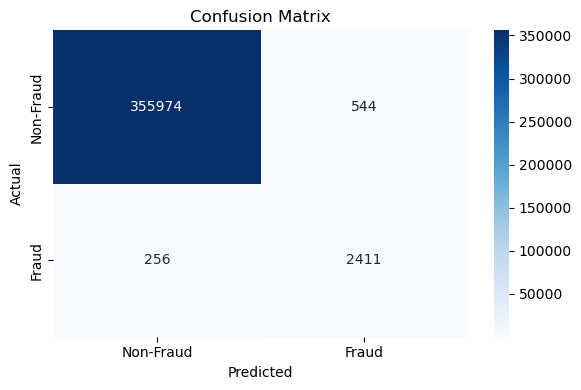

Recall/True Positive Rate: The model got 90.4% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 81.59% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 0.15% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [27]:
y_prob = pipeline.pipeline.predict_proba(X_test)[:, 1]
plot_confusion_matrix(y_test, y_prob, 0.5)

# Feature Importance

In [9]:
# Feature importance
importance_df = pipeline.get_feature_importance(X_train, y_train)

Getting feature importances...
Using built-in feature_importances_ from the model.


In [10]:
import pandas as pd
pd.set_option("display.max_rows", None)
importance_df

,feature,importance
278,CardProduct,0.046700
265,AgeOfActiveCardTxn,0.045333
264,AgeOfOpenAcctTxn,0.044100
261,CustomerAge,0.034567
277,CashCreditLimit,0.027967
276,CreditLimit,0.026900
256,Transaction Amount,0.024467
248,CntUnique_CardNo_by_currencyCode_L90D,0.023200
241,CntUnique_CardNo_by_cardAcceptor_cat_L90D,0.022667
267,TotalTrxAmountL7D,0.022467


# Save Training Artifacts

In [13]:
importance_df.reset_index(drop=True).to_csv("data/result/credit_model_feature_importance_lgb.csv")

In [20]:
# get model
clf = pipeline.get_model()

Returning trained model...


# Back-Testing with OOS Data

In [28]:
df_credit_mix = pd.read_parquet("data/base/df_credit_clean_dec24_may25.parquet")
trx_id_list = list(df_credit_mix[df_credit_mix.Confirmed.isin([0,1])]['Transaction Serial No'])
df_oos_new = df_splits["df_test"][df_splits["df_test"].index.isin(trx_id_list)]

In [29]:
X_oos, y_oos = pipeline.prepare_data(
    df=df_splits["df_test"],
    # df=df_oos_new,
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_training=False # set to False for back-testing/predicting OOS data
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
  Float columns to downcast: ['time_diff', 'TxnCount_L15M', 'TxnCount_L1H', 'TxnCount_L1D', 'TxnCount_L7D', 'TxnCount_L14D', 'TxnCount_L30D', 'TxnCount_L90D', 'TxnCount_to_MCC_L15M', 'TxnCount_to_MCC_L1H', 'TxnCount_to_MCC_L1D', 'TxnCount_to_MCC_L7D', 'TxnCount_to_MCC_L14D', 'TxnCount_to_MCC_L30D', 'TxnCount_to_MCC_L90D', 'TxnCount_to_MCC_details_L15M', 'TxnCount_to_MCC_details_L1H', 'TxnCount_to_MCC_details_L1D', 'TxnCount_to_MCC_details_L7D', 'TxnCount_to_MCC_details_L14D', 'TxnCount_to_MCC_details_L30D', 'TxnCount_to_MCC_details_L90D', 'TxnCount_to_MCC_catcode_L15M', 'TxnCount_to_MCC_catcode_L1H', 'TxnCount_to_MCC_catcode_L1D', 'TxnCount_to_MCC_catcode_L7D', 'TxnCount_to_MCC_catcode_L14D', 'TxnCount_to_MCC_catcode_L30D', 'TxnCount_to_MCC_catcode_L90D', 'TxnCount_to_MCC_cat_L15M', 'TxnCount_to_MCC_cat_L1H', 'TxnCount_to_MCC_cat_L1D', 'TxnCount_to_MCC_cat_L7D', 'TxnCount_to_MCC_cat_L14D', 'TxnCoun

In [30]:
# Evaluate
oos_results = pipeline.evaluate(X_oos, y_oos)

Evaluating model...
Accuracy: 0.9957
AUC: 0.9844
PR AUC: 0.7213
Precision: 0.7862
Recall: 0.5818

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00    200054
        True       0.79      0.58      0.67      1492

    accuracy                           1.00    201546
   macro avg       0.89      0.79      0.83    201546
weighted avg       1.00      1.00      1.00    201546



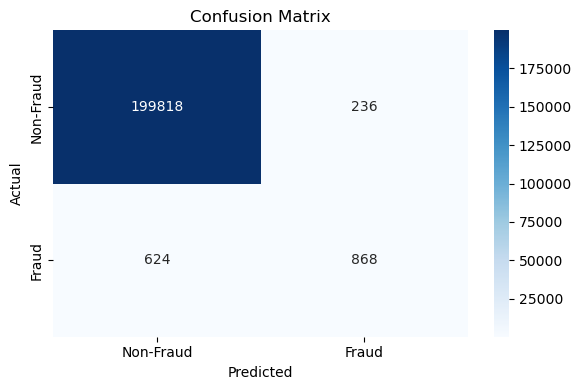

Recall/True Positive Rate: The model got 58.18% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 78.62% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 0.12% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [31]:
y_oos_prob = pipeline.pipeline.predict_proba(X_oos)[:, 1]
plot_confusion_matrix(y_oos, y_oos_prob, 0.5)

## Evaluation ALERT Transaction Only

In [32]:
# Evaluate ALERT trx only
X_oos_new, y_oos_new = pipeline.prepare_data(
    # df=df_splits["df_test"],
    df=df_oos_new,
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_training=False # set to False for back-testing/predicting OOS data
)

# Evaluate ALERT trx only
oos_results = pipeline.evaluate(X_oos_new, y_oos_new)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
  Float columns to downcast: ['time_diff', 'TxnCount_L15M', 'TxnCount_L1H', 'TxnCount_L1D', 'TxnCount_L7D', 'TxnCount_L14D', 'TxnCount_L30D', 'TxnCount_L90D', 'TxnCount_to_MCC_L15M', 'TxnCount_to_MCC_L1H', 'TxnCount_to_MCC_L1D', 'TxnCount_to_MCC_L7D', 'TxnCount_to_MCC_L14D', 'TxnCount_to_MCC_L30D', 'TxnCount_to_MCC_L90D', 'TxnCount_to_MCC_details_L15M', 'TxnCount_to_MCC_details_L1H', 'TxnCount_to_MCC_details_L1D', 'TxnCount_to_MCC_details_L7D', 'TxnCount_to_MCC_details_L14D', 'TxnCount_to_MCC_details_L30D', 'TxnCount_to_MCC_details_L90D', 'TxnCount_to_MCC_catcode_L15M', 'TxnCount_to_MCC_catcode_L1H', 'TxnCount_to_MCC_catcode_L1D', 'TxnCount_to_MCC_catcode_L7D', 'TxnCount_to_MCC_catcode_L14D', 'TxnCount_to_MCC_catcode_L30D', 'TxnCount_to_MCC_catcode_L90D', 'TxnCount_to_MCC_cat_L15M', 'TxnCount_to_MCC_cat_L1H', 'TxnCount_to_MCC_cat_L1D', 'TxnCount_to_MCC_cat_L7D', 'TxnCount_to_MCC_cat_L14D', 'TxnCoun

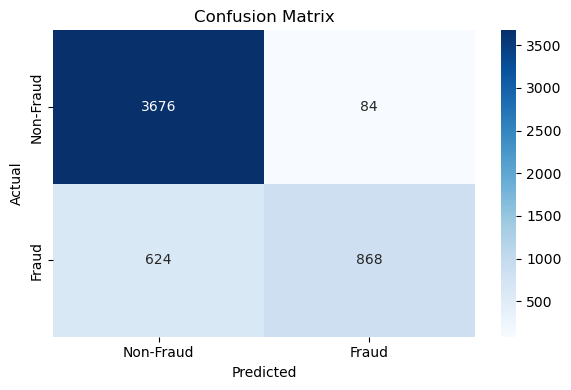

Recall/True Positive Rate: The model got 58.18% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 91.18% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 2.23% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [33]:
y_oos_new_prob = pipeline.pipeline.predict_proba(X_oos_new)[:, 1]
plot_confusion_matrix(y_oos_new, y_oos_new_prob, 0.5)

# CV Eval

In [12]:
pipeline.build_pipeline()
cv_scores = pipeline.cross_validate(X, y, cv=5)
print("CV Scores:", cv_scores)

Building pipeline...
Pipeline built.
Starting cross-validation...


CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

Training fold 1/5...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 13885, number of negative: 702463
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.365277 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 65330
[LightGBM] [Info] Number of data points in the train set: 716348, number of used features: 303
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Fold 1/5 AUC: 0.9992
Training fold 2/5...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 13886, number of negative: 702463
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.577533 seconds.
You can set `force_col_wise=true` to re